In [22]:
# D2C CUSTOMER CHURN CAPSTONE
# PART 2 : RFM SEGMENTATION & RETENTION STRATEGY

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

import os

# Create output folder
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

from pathlib import Path
import pandas as pd

DATA_PATH = Path("data") / "rfm_modeling_snapshot.csv"

df = pd.read_csv(DATA_PATH)


print(df.shape)
df.head()

(2400, 29)


,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,362.73,0.0,0.23,3.0,1,0,0.0,0.0,524,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,581.00,0.0,0.23,4.0,1,1,0.0,1.0,121,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,649.98,0.0,0.47,2.0,1,0,0.0,0.0,206,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,1604.04,0.0,0.16,2.0,1,0,0.0,0.0,168,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,1781.90,0.0,0.48,1.0,2,0,0.0,0.0,405,18,95,4,1,1,3,1,9,0,train


In [23]:
# 2. BASIC CHECKS

print(df.info())

print("\nMissing Values")
print(df.isnull().sum().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               2400 non-null   object 
 1   snapshot_date             2400 non-null   object 
 2   city_tier                 2400 non-null   object 
 3   age_group                 2400 non-null   object 
 4   acquisition_channel       2400 non-null   object 
 5   loyalty_tier              1014 non-null   object 
 6   preferred_category        2400 non-null   object 
 7   marketing_consent         2400 non-null   object 
 8   recency_days              2400 non-null   int64  
 9   frequency_180d            2400 non-null   int64  
 10  monetary_180d             2400 non-null   float64
 11  return_rate_180d          2400 non-null   float64
 12  avg_discount_pct_180d     2400 non-null   float64
 13  avg_rating_180d           2400 non-null   float64
 14  category

In [24]:

# 3. RFM SCORING

# 1. Recency
df["R_score"] = pd.qcut(
    df["recency_days"].rank(method="first"),
    5,
    labels=[5,4,3,2,1]
).astype(int)

# 2.  Frequency
df["F_score"] = pd.qcut(
    df["frequency_180d"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
).astype(int)

# 3. Monetary
df["M_score"] = pd.qcut(
    df["monetary_180d"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
).astype(int)

# 4. Combined RFM score
df["RFM_score"] = (
    df["R_score"] +
    df["F_score"] +
    df["M_score"]
)

print(df[["R_score","F_score","M_score","RFM_score"]].head())



   R_score  F_score  M_score  RFM_score
0        2        1        1          4
1        4        1        2          7
2        1        1        2          4
3        2        1        4          7
4        4        5        4         13


In [25]:

# SEGMENT LOGIC DOCUMENTATION

segment_rules = pd.DataFrame({

    "Segment":[
        "Champions",
        "Loyal Customers",
        "High Value But Unhappy",
        "Discount Sensitive",
        "At Risk",
        "Dormant Customers"
    ],

    "Logic":[
        "High R,F,M and active sessions",
        "High RFM score and repeat purchases",
        "High spending customers with repeated complaints",
        "High discount dependency",
        "High spend but inactive recently",
        "Low spend and low engagement"
    ]
})

print(segment_rules)


                  Segment                                             Logic
0               Champions                    High R,F,M and active sessions
1         Loyal Customers               High RFM score and repeat purchases
2  High Value But Unhappy  High spending customers with repeated complaints
3      Discount Sensitive                          High discount dependency
4                 At Risk                  High spend but inactive recently
5       Dormant Customers                      Low spend and low engagement


In [26]:
# 4. THRESHOLDS

median_monetary = df["monetary_180d"].median()
median_sessions = df["sessions_30d"].median()

print("Median Monetary:", median_monetary)
print("Median Sessions:", median_sessions)


Median Monetary: 911.875
Median Sessions: 5.0


In [27]:
# 5. CUSTOMER SEGMENTATION

def assign_segment(row):

    # Champions
    if (
        row["R_score"] >= 4 and
        row["F_score"] >= 4 and
        row["M_score"] >= 4 and
        row["sessions_30d"] >= median_sessions
    ):
        return "Champions"

    # High Value But Unhappy
    elif (
        row["monetary_180d"] > median_monetary
        and
        (
            row["ticket_count_90d"] >= 2
            or
            row["negative_ticket_rate_90d"] > 0.50
        )
    ):
        return "High Value But Unhappy"

    # Loyal
    elif (
        row["RFM_score"] >= 10 and
        row["frequency_180d"] >= 2
    ):
        return "Loyal Customers"

    # Discount Sensitive
    elif (
        row["avg_discount_pct_180d"] > 0.35
    ):
        return "Discount Sensitive"

    # At Risk
    elif (
        row["recency_days"] > 120 and
        row["monetary_180d"] > median_monetary
    ):
        return "At Risk"

    else:
        return "Dormant Customers"

df["segment_name"] = df.apply(assign_segment, axis=1)

In [28]:
# 6. SEGMENT DISTRIBUTION

segment_counts = (
    df["segment_name"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = [
    "Segment",
    "Customers"
]

print(segment_counts)


                  Segment  Customers
0       Dormant Customers       1036
1         Loyal Customers        536
2      Discount Sensitive        326
3               Champions        285
4  High Value But Unhappy        140
5                 At Risk         77


In [29]:
# 7. SEGMENT SUMMARY TABLE

segment_summary = (
    df.groupby("segment_name")
    .agg(
        customers=("customer_id","count"),
        avg_recency=("recency_days","mean"),
        avg_frequency=("frequency_180d","mean"),
        avg_monetary=("monetary_180d","mean"),
        avg_sessions=("sessions_30d","mean"),
        avg_discount=("avg_discount_pct_180d","mean"),
        avg_return_rate=("return_rate_180d","mean")
    )
    .round(2)
)

print(segment_summary)


                        customers  avg_recency  avg_frequency  avg_monetary  \
segment_name                                                                  
At Risk                        77       150.22           1.25       1296.04   
Champions                     285        18.93           3.20       2473.55   
Discount Sensitive            326        76.12           1.10        642.06   
Dormant Customers            1036       123.53           0.75        525.59   
High Value But Unhappy        140        46.17           2.44       1976.28   
Loyal Customers               536        62.47           2.52       1858.53   

                        avg_sessions  avg_discount  avg_return_rate  
segment_name                                                         
At Risk                         3.38          0.21             0.05  
Champions                       9.60          0.28             0.07  
Discount Sensitive              5.16          0.44             0.07  
Dormant Customers

In [30]:
# 8. SEGMENT-WISE CHURN ANALYSIS

segment_churn = (
    df.groupby("segment_name")
    .agg(
        customers=("customer_id","count"),
        churned=("churn_next_60d","sum")
    )
)

segment_churn["churn_rate"] = (
    segment_churn["churned"]
    /
    segment_churn["customers"]
    *100
)

segment_churn = segment_churn.round(2)

print(segment_churn)


                        customers  churned  churn_rate
segment_name                                          
At Risk                        77       67       87.01
Champions                     285       22        7.72
Discount Sensitive            326      185       56.75
Dormant Customers            1036      645       62.26
High Value But Unhappy        140       49       35.00
Loyal Customers               536      159       29.66


In [31]:
# 9. SEGMENT-WISE REVENUE CONTRIBUTION

segment_revenue = (
    df.groupby("segment_name")
    .agg(
        total_revenue=("monetary_180d","sum")
    )
)

total_revenue = segment_revenue[
    "total_revenue"
].sum()

segment_revenue["revenue_share_pct"] = (
    segment_revenue["total_revenue"]
    /
    total_revenue
    *100
)

segment_revenue = segment_revenue.round(2)
print(segment_revenue)

                        total_revenue  revenue_share_pct
segment_name                                            
At Risk                      99795.30               3.52
Champions                   704961.14              24.90
Discount Sensitive          209312.77               7.39
Dormant Customers           544513.52              19.23
High Value But Unhappy      276678.88               9.77
Loyal Customers             996170.06              35.18


In [32]:
# 10. RETENTION ACTIONS
retention_actions = pd.DataFrame({

    "Segment":[
        "Champions",
        "Loyal Customers",
        "At Risk",
        "High Value But Unhappy",
        "Discount Sensitive",
        "Dormant Customers"
    ],

    "Retention Action":[
        "VIP rewards and early access",
        "Cross-sell and loyalty points",
        "Personalized win-back campaigns",
        "Dedicated support manager and service recovery",
        "Coupons and bundle offers",
        "Reactivation campaigns"
    ]
})

print(retention_actions)


                  Segment                                Retention Action
0               Champions                    VIP rewards and early access
1         Loyal Customers                   Cross-sell and loyalty points
2                 At Risk                 Personalized win-back campaigns
3  High Value But Unhappy  Dedicated support manager and service recovery
4      Discount Sensitive                       Coupons and bundle offers
5       Dormant Customers                          Reactivation campaigns


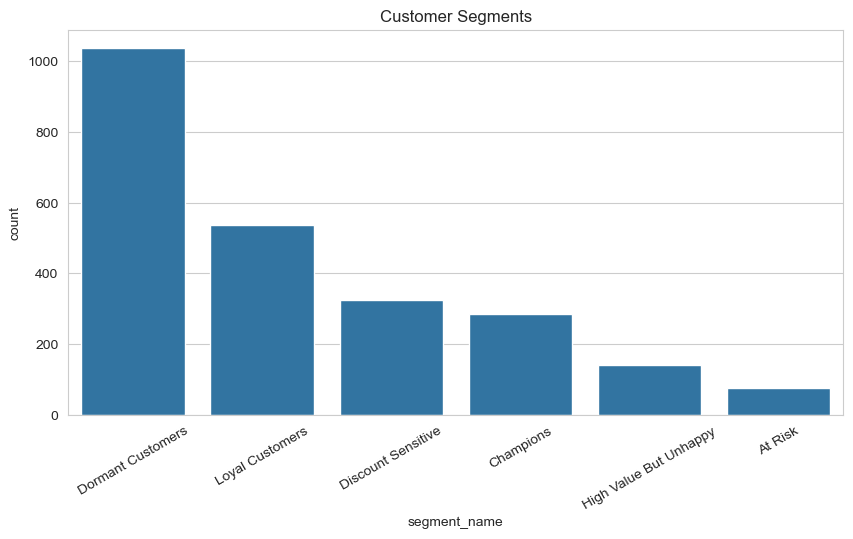

In [33]:
# 11. VISUALIZATION
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="segment_name",
    order=df["segment_name"].value_counts().index
)

plt.xticks(rotation=30)
plt.title("Customer Segments")
plt.show()


In [34]:
# 12. SAVE SEGMENTS.CSV
segments = df[
    [
        "customer_id",
        "segment_name",
        "recency_days",
        "frequency_180d",
        "monetary_180d",
        "sessions_30d",
        "ticket_count_90d",
        "return_rate_180d",
        "category_diversity_180d",
        "campaign_clicks_30d",
        "churn_next_60d"
    ]
]

segments.to_csv(
    os.path.join(OUTPUT_DIR, "segments.csv"),
    index=False
)

print("segments.csv saved successfully")


segments.csv saved successfully


In [35]:
# 13. PRIORITY CUSTOMERS FOR RETENTION
priority_customers = df[
    df["segment_name"]=="At Risk"
].sort_values(
    by="monetary_180d",
    ascending=False
)
print(priority_customers.head(20))


     customer_id snapshot_date city_tier age_group acquisition_channel  \
1027   CUST01028    2025-09-30    Tier 2     25-34             Organic   
855    CUST00856    2025-09-30    Tier 1     18-24          Influencer   
1052   CUST01053    2025-09-30    Tier 1     18-24          Influencer   
708    CUST00709    2025-09-30    Tier 1     18-24           Instagram   
1776   CUST01777    2025-09-30    Tier 2     18-24         Marketplace   
1756   CUST01757    2025-09-30    Tier 2       45+       Google Search   
1078   CUST01079    2025-09-30    Tier 2     25-34       Google Search   
496    CUST00497    2025-09-30    Tier 1     25-34            Referral   
56     CUST00057    2025-09-30    Tier 2     25-34       Google Search   
182    CUST00183    2025-09-30    Tier 2     25-34           Instagram   
795    CUST00796    2025-09-30    Tier 2     18-24          Influencer   
3      CUST00004    2025-09-30    Tier 3     25-34       Google Search   
959    CUST00960    2025-09-30    Tier

In [36]:
# 14. SEGMENT PERCENTAGES
segment_percent = (
    df["segment_name"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(segment_percent)

segment_name
Dormant Customers         43.17
Loyal Customers           22.33
Discount Sensitive        13.58
Champions                 11.88
High Value But Unhappy     5.83
At Risk                    3.21
Name: proportion, dtype: float64


In [37]:
# 15. PRIORITY ANALYSIS

priority_analysis = (
    df.groupby("segment_name")
    .agg(
        customers=("customer_id","count"),
        avg_revenue=("monetary_180d","mean"),
        churn_rate=("churn_next_60d","mean")
    )
)

priority_analysis["churn_rate"] *= 100

priority_analysis = priority_analysis.round(2)

print(priority_analysis)


                        customers  avg_revenue  churn_rate
segment_name                                              
At Risk                        77      1296.04       87.01
Champions                     285      2473.55        7.72
Discount Sensitive            326       642.06       56.75
Dormant Customers            1036       525.59       62.26
High Value But Unhappy        140      1976.28       35.00
Loyal Customers               536      1858.53       29.66


                        customers    revenue  churn_rate
segment_name                                            
At Risk                        77   99795.30       87.01
Champions                     285  704961.14        7.72
Discount Sensitive            326  209312.77       56.75
Dormant Customers            1036  544513.52       62.26
High Value But Unhappy        140  276678.88       35.00
Loyal Customers               536  996170.06       29.66


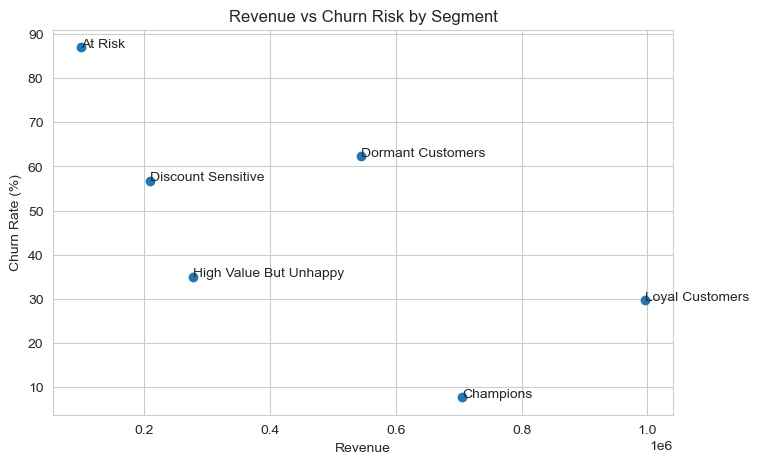

In [38]:
# 16. CHURN VS REVENUE MATRIX

business_priority = (
    df.groupby("segment_name")
    .agg(
        customers=("customer_id","count"),
        revenue=("monetary_180d","sum"),
        churn_rate=("churn_next_60d","mean")
    )
)

business_priority["churn_rate"] *= 100

business_priority = business_priority.round(2)

print(business_priority)

plt.figure(figsize=(8,5))

plt.scatter(
    business_priority["revenue"],
    business_priority["churn_rate"]
)

for i in business_priority.index:

    plt.annotate(
        i,
        (
            business_priority.loc[i,"revenue"],
            business_priority.loc[i,"churn_rate"]
        )
    )

plt.xlabel("Revenue")
plt.ylabel("Churn Rate (%)")
plt.title("Revenue vs Churn Risk by Segment")

plt.show()


In [39]:
# 17. RETENTION BUDGET ALLOCATION

budget = 100000

allocation = {

    "At Risk": 0.40,
    "Loyal Customers": 0.25,
    "Champions": 0.15,
    "High Value But Unhappy": 0.10,
    "Discount Sensitive": 0.05,
    "Dormant Customers": 0.05
}

budget_df = pd.DataFrame(
    allocation.items(),
    columns=["Segment","Allocation"]
)

budget_df["Budget_INR"] = (
    budget_df["Allocation"] * budget
).astype(int)

print(budget_df)


                  Segment  Allocation  Budget_INR
0                 At Risk        0.40       40000
1         Loyal Customers        0.25       25000
2               Champions        0.15       15000
3  High Value But Unhappy        0.10       10000
4      Discount Sensitive        0.05        5000
5       Dormant Customers        0.05        5000


In [40]:
print("""
BUSINESS JUSTIFICATION

At Risk customers receive the highest budget because:

1. They have high historical spending.
2. They are becoming inactive.
3. They have elevated churn risk.
4. Recovering them is cheaper than acquiring new customers.

A separate segment called 'High Value But Unhappy'
was created by combining spending behavior with
customer support complaints.

This ensures retention resources are focused on
valuable customers who are dissatisfied and at
risk of churn rather than spending resources on
all customers with complaints.
""")

# 18. MANUAL REVIEW CASES

review_cases = pd.concat([

    df[
        (df["sessions_30d"] == 0) &
        (
            df["monetary_180d"] >
            df["monetary_180d"].quantile(0.75)
        )
    ],

    df[
        (df["ticket_count_90d"] >= 2) &
        (df["RFM_score"] >= 10)
    ],

    df[
        (df["recency_days"] > 180) &
        (df["frequency_180d"] >= 3)
    ]

])

review_cases = review_cases.drop_duplicates(
    subset="customer_id"
)

review_cases = review_cases.head(10)

print("\nMANUAL REVIEW CUSTOMERS")
print(
    review_cases[
        [
            "customer_id",
            "segment_name",
            "recency_days",
            "frequency_180d",
            "monetary_180d",
            "sessions_30d",
            "ticket_count_90d",
            "negative_ticket_rate_90d"
        ]
    ]
)
# 19. MANUAL REVIEW DECISIONS

for _, row in review_cases.iterrows():

    print("\n" + "="*60)

    print("Customer:", row["customer_id"])
    print("Segment:", row["segment_name"])

    if row["ticket_count_90d"] >= 2:

        print("Reason: Multiple support complaints.")
        print("Decision: Escalate to customer success team.")

    elif row["sessions_30d"] == 0:

        print("Reason: High-value customer but no recent activity.")
        print("Decision: Send personalized re-engagement campaign.")

    elif row["recency_days"] > 180:

        print("Reason: Previously active customer becoming inactive.")
        print("Decision: Include in win-back campaign.")

    else:

        print("Decision: Monitor for next 30 days.")

review_cases.to_csv(
    os.path.join(OUTPUT_DIR, "manual_review_customers.csv"),
    index=False
)

print("manual_review_customers.csv saved")

# 20. EXPORT SUMMARY FILES

segment_summary.to_csv(
    os.path.join(OUTPUT_DIR, "segment_summary.csv")
)

budget_df.to_csv(
    os.path.join(OUTPUT_DIR, "budget_allocation.csv"),
    index=False
)


segment_churn.to_csv(
    os.path.join(OUTPUT_DIR, "segment_churn.csv")
)

segment_revenue.to_csv(
    os.path.join(OUTPUT_DIR, "segment_revenue.csv")
)


retention_actions.to_csv(
    os.path.join(OUTPUT_DIR, "retention_actions.csv"),
    index=False
)

print("\nAll outputs generated successfully.")


BUSINESS JUSTIFICATION

At Risk customers receive the highest budget because:

1. They have high historical spending.
2. They are becoming inactive.
3. They have elevated churn risk.
4. Recovering them is cheaper than acquiring new customers.

A separate segment called 'High Value But Unhappy'
was created by combining spending behavior with
customer support complaints.

This ensures retention resources are focused on
valuable customers who are dissatisfied and at
risk of churn rather than spending resources on
all customers with complaints.


MANUAL REVIEW CUSTOMERS
    customer_id            segment_name  recency_days  frequency_180d  \
35    CUST00036         Loyal Customers            27               4   
96    CUST00097         Loyal Customers             1               3   
124   CUST00125         Loyal Customers             8               2   
331   CUST00332  High Value But Unhappy            24               2   
358   CUST00359         Loyal Customers             3        